# TP6 - SVM
### Sharaine MALARVIJY 21206543

## I. Plan séparateur

In [12]:
from TP6_ETU import *
from sklearn import svm
from cvxopt.solvers import qp
from cvxopt import matrix

X = np.array([[0,0], [2,2], [2,0], [3, 0]])
y = np.array([-1, -1, 1, 1])

bornex=[min(X[:,0])-1,max(X[:,0])+1] 
borney=[min(X[:,1])-1,max(X[:,1])+1] 

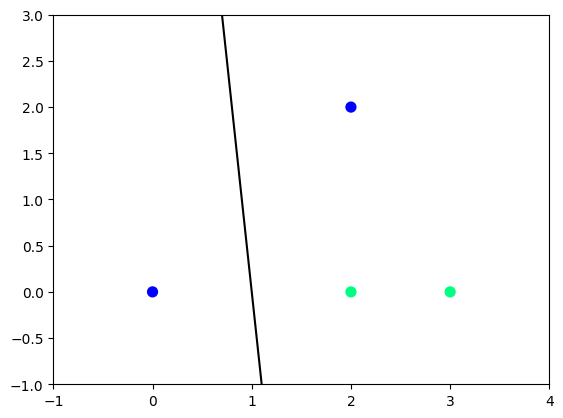

In [13]:
w = np.array([1, 0.1])
b = -1

def affichePlan(w, b, bornex):
    x = np.linspace(bornex[0], bornex[1], 100)
    y_decision = -(w[0] * x + b) / w[1]
    plt.plot(x, y_decision, 'k-') 

aff_donnees(X, y, bornex, borney, 50)
affichePlan(w, b, bornex)

Ce n'est pas un hyperplan séparateur car il ne prend pas en compte la classe des points

## II. SVM linéaire dans le primal

     pcost       dcost       gap    pres   dres
 0:  3.2653e-01  1.9592e+00  6e+00  2e+00  4e+00
 1:  1.5796e+00  8.5663e-01  7e-01  2e-16  8e-16
 2:  1.0195e+00  9.9227e-01  3e-02  6e-16  2e-15
 3:  1.0002e+00  9.9992e-01  3e-04  2e-16  8e-16
 4:  1.0000e+00  1.0000e+00  3e-06  2e-16  3e-15
 5:  1.0000e+00  1.0000e+00  3e-08  2e-16  1e-15
Optimal solution found.
[ 1.00e+00]
[-1.00e+00]
[-1.00e+00]



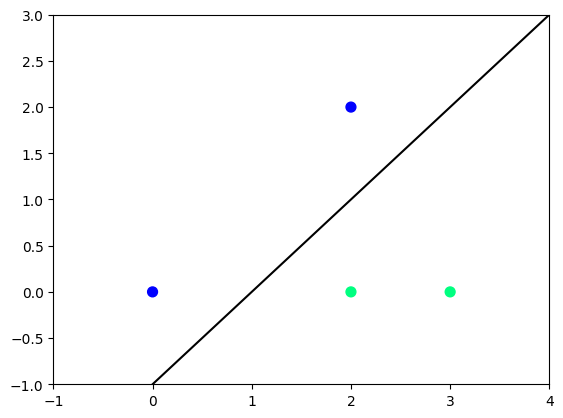

In [14]:
def ResoudPrimal(X, y):
    N, n = X.shape

    P = np.zeros((n+1, n+1))
    P[:n, :n] = np.identity(n)
    q = np.zeros((n+1, 1))

    G = -(np.concatenate((y[:, None] * X, y[:, None]), axis=1))
    h = -np.ones((N, 1))

    P = matrix(P, tc='d')
    q = matrix(q, tc='d')
    G = matrix(G, tc='d')
    h = matrix(h, tc='d')

    sol = qp(P, q, G, h)
    print(sol['x'])
    z = np.array(sol['x']).flatten()
    b = z[n]
    w = z[:n]
    return w, b

X = np.array([[0,0], [2,2], [2,0], [3, 0]])
y = np.array([-1, -1, 1, 1])
w, b = ResoudPrimal(X, y)
aff_donnees(X, y, bornex, borney, 50)
affichePlan(w, b, bornex)


Cette hyperplan est correct

     pcost       dcost       gap    pres   dres
 0:  1.8212e-01  5.5124e+00  1e+01  2e+00  5e+00
 1:  5.5352e-01  1.0158e+01  5e+00  1e+00  3e+00
 2:  1.0266e+00  4.3072e+01  7e+00  1e+00  3e+00
 3:  9.6056e+00  1.2385e+02  2e+01  1e+00  2e+00
 4:  5.1885e+02  2.6193e+02  3e+02  4e-15  1e-10
 5:  3.2241e+02  3.1119e+02  1e+01  1e-15  3e-11
 6:  3.1309e+02  3.1298e+02  1e-01  1e-14  3e-11
 7:  3.1300e+02  3.1300e+02  1e-03  4e-15  3e-11
 8:  3.1300e+02  3.1300e+02  1e-05  5e-15  2e-11
Optimal solution found.
[ 2.50e+01]
[-1.00e+00]
[-4.90e+01]



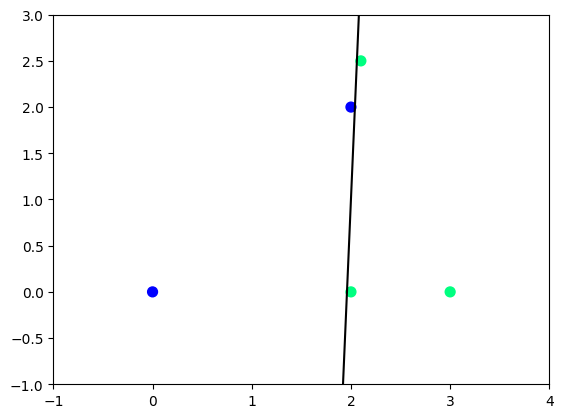

In [15]:
X = np.array([[0,0], [2,2], [2,0], [3, 0], [2.1, 2.5]])
y = np.array([-1, -1, 1, 1, 1])
w, b = ResoudPrimal(X, y)
aff_donnees(X, y, bornex, borney, 50)
affichePlan(w, b, bornex)

L'hyperplan fonctionne mais on a une marge très petite.

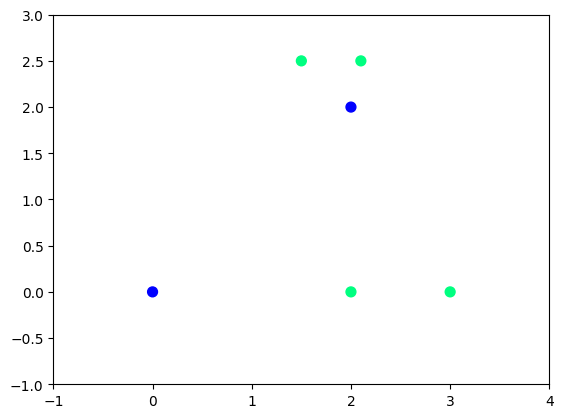

In [16]:
X = np.array([[0,0], [2,2], [2,0], [3, 0], [2.1, 2.5], [1.5, 2.5]])
y = np.array([-1, -1, 1, 1, 1, 1])
# w, b = ResoudPrimal(X, y)
aff_donnees(X, y, bornex, borney, 50)
# affichePlan(w, b, bornex)

Le probleme étant non linéaire la fonction nous renvoi une erreur car il n'y pas de solution pour séparer tout les points.

## III. SVM à marge souple

La variable C règle le compromis entre une grande marge et le respect des contraintes

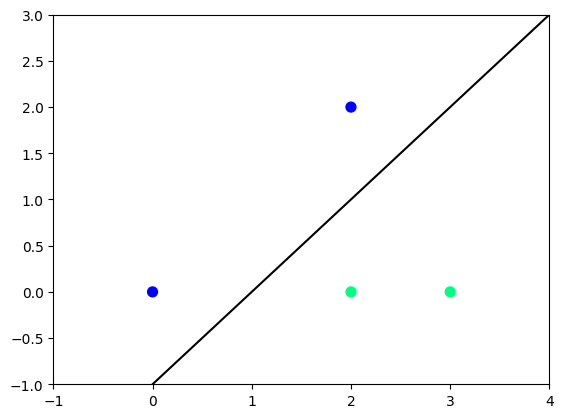

In [17]:
X = np.array([[0,0], [2,2], [2,0], [3, 0]])
y = np.array([-1, -1, 1, 1])

def plot_svm(X, y, C=1):
    bornex=[min(X[:,0])-1,max(X[:,0])+1] 
    borney=[min(X[:,1])-1,max(X[:,1])+1] 
    
    model = svm.SVC(kernel='linear', C=C)
    model.fit(X, y)
    w = model.coef_[0] 
    b = model.intercept_[0]

    aff_donnees(X, y, bornex, borney, 50)
    affichePlan(w, b, bornex)
plot_svm(X, y)

On voit que la SVM fonctionne comme attendu

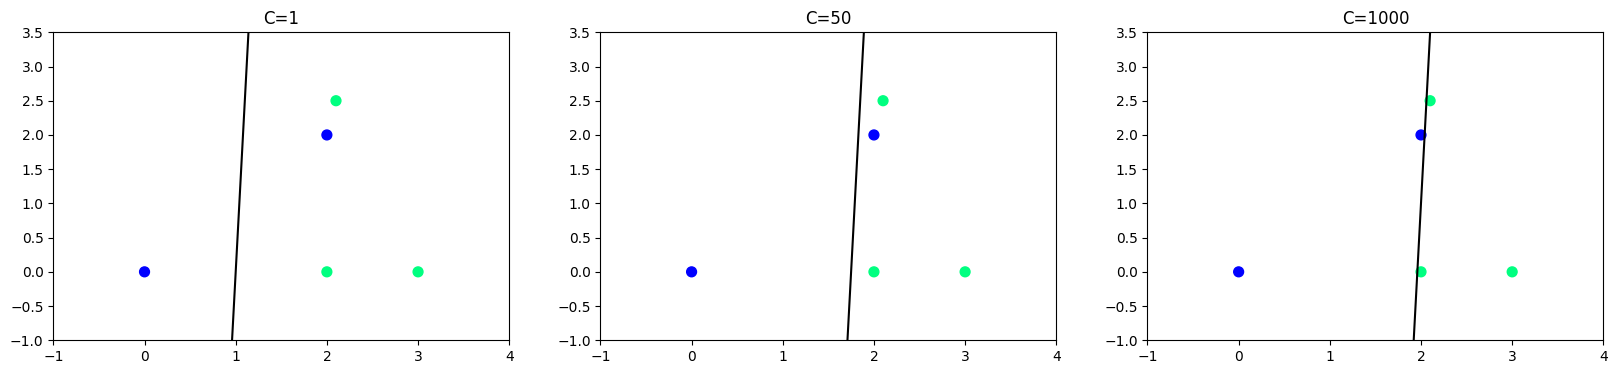

In [18]:
X = np.array([[0,0], [2,2], [2,0], [3, 0], [2.1, 2.5]])
y = np.array([-1, -1, 1, 1, 1])
def plot_3_svm(X, y):
    plt.figure(figsize=(20, 4))
    
    C=1
    plt.subplot(1, 3, 1)
    plot_svm(X, y, C)
    plt.title(f"C={C}")

    C=50
    plt.subplot(1, 3, 2)
    plot_svm(X, y, C)
    plt.title(f"C={C}")

    C=1000
    plt.subplot(1, 3, 3)
    plot_svm(X, y, C)
    plt.title(f"C={C}")
plot_3_svm(X, y)

Si C est petit, la marge sera plus grande car on est plus laxiste sur les données mal classées.

Si C est grand, la marge sera petite pour que le maximum de point soit bien classé

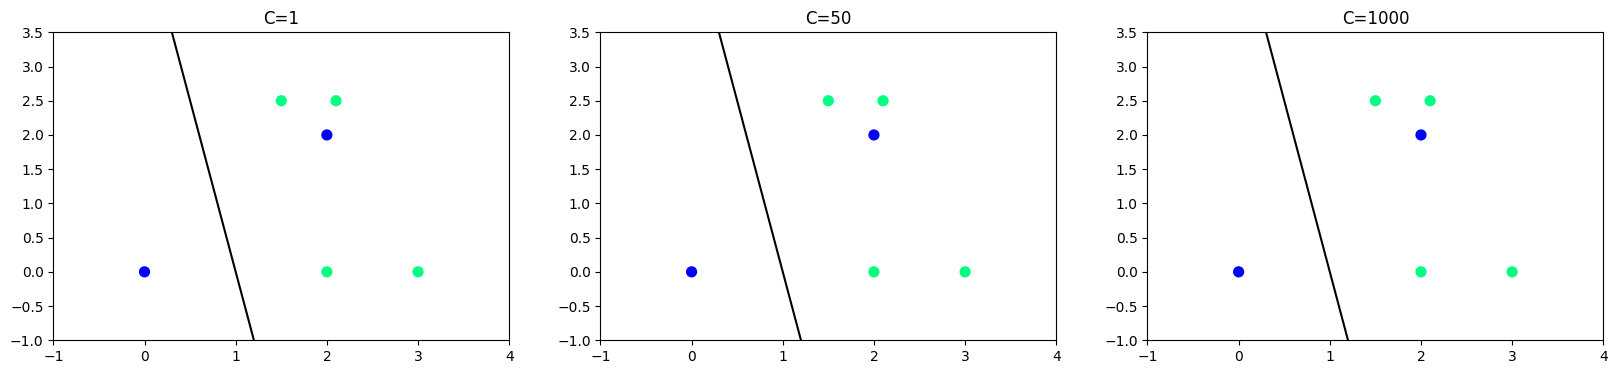

In [19]:
X = np.array([[0,0], [2,2], [2,0], [3, 0], [2.1, 2.5], [1.5, 2.5]])
y = np.array([-1, -1, 1, 1, 1, 1])

plot_3_svm(X, y)

On voit que le probleme n'a pas de solution linéaire donc peut importe C on a une solution qui maximise la marge.

## IV.  SVM avec Kernel

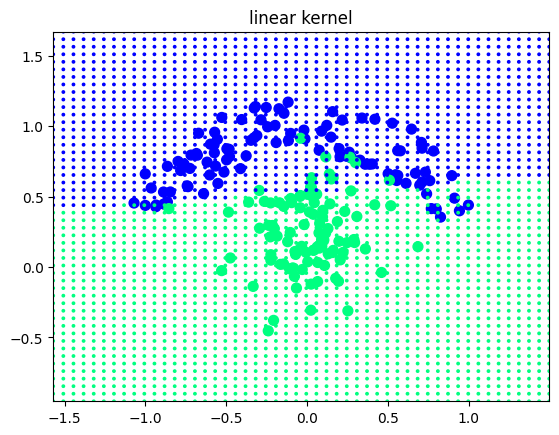

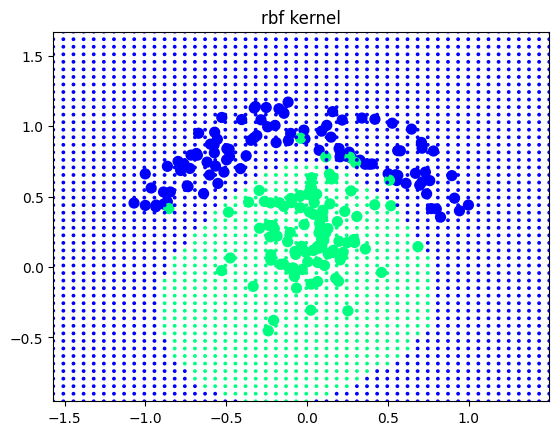

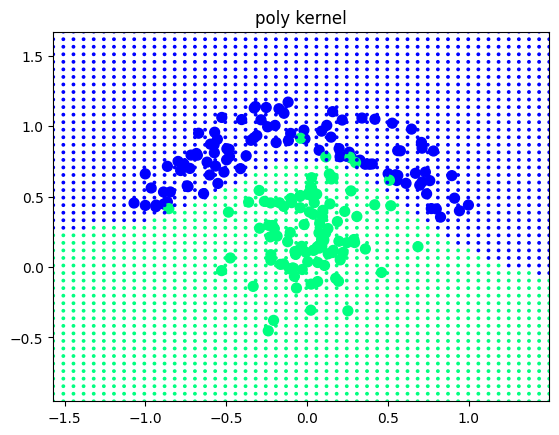

In [22]:
f = np.load('TP6.npz',allow_pickle=True) 
X=f['arr_0'] 
y=f['arr_1'].ravel()

contour = 0.5
bornex=[min(X[:,0])-contour,max(X[:,0])+contour] 
borney=[min(X[:,1])-contour,max(X[:,1])+contour] 

for k in ['linear', 'rbf', 'poly']:
    model = svm.SVC(kernel=k, C=1)
    model.fit(X, y)

    aff_frontiere(X,y,bornex,borney,model)
    plt.title(f"{k} kernel")
    plt.show()

On peut apprendre des frontières non linéaires avec un noyau linéaire mais la solution ne sera pas très bonne.

Avec un noyau rbf, on voit que la frontière est un sorte de cercle. C'est un noyau bien adapté mais le noyau polynomial est un peu mieux adapté.

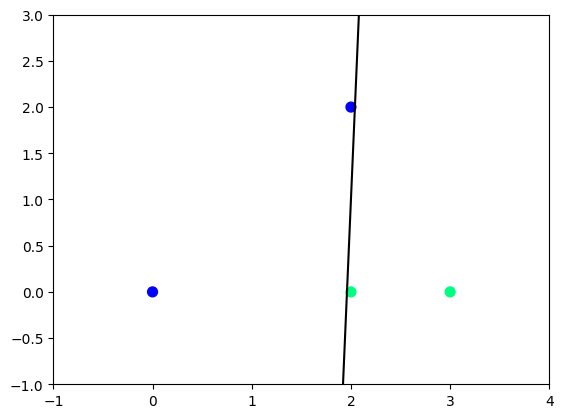

In [21]:
X = np.array([[0,0], [2,2], [2,0], [3, 0]])
y = np.array([-1, -1, 1, 1])

bornex=[min(X[:,0])-1,max(X[:,0])+1] 
borney=[min(X[:,1])-1,max(X[:,1])+1] 

model = svm.SVC(kernel='rbf', C=1)
model.fit(X, y)

aff_donnees(X, y, bornex, borney, 50)
affichePlan(w, b, bornex)
plt.show()

La marge est petite pour que le maximum de point soit bien classé. C'est donc comme si on avait un C très grand avec un noyau linéaire. Il est donc plus judicieux d'utiliser une noyau linéaire où on peut contrôler le compromis C.